In [1]:
# load the packages

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import dask.dataframe as dd

In [2]:
# loading path for 3 dataset

df_jan_path = r"..\data\raw\yellow_tripdata_2016-01.csv"
df_feb_path = r"..\data\raw\yellow_tripdata_2016-02.csv"
df_mar_path = r"..\data\raw\yellow_tripdata_2016-03.csv"

In [3]:
# loading dataframes and dropping unwanted columns

df_jan = dd.read_csv(df_jan_path,assume_missing=True,usecols = ['trip_distance', 'pickup_longitude',
       'pickup_latitude','dropoff_longitude', 'dropoff_latitude', 'fare_amount'])

df_feb = dd.read_csv(df_feb_path,assume_missing=True,usecols = ['trip_distance', 'pickup_longitude',
       'pickup_latitude','dropoff_longitude', 'dropoff_latitude', 'fare_amount'])

df_mar = dd.read_csv(df_mar_path,assume_missing=True,usecols = ['trip_distance', 'pickup_longitude',
       'pickup_latitude','dropoff_longitude', 'dropoff_latitude', 'fare_amount'])

In [4]:
df_jan

,trip_distance,pickup_longitude,pickup_latitude,dropoff_longitude,dropoff_latitude,fare_amount
npartitions=26,,,,,,
,float64,float64,float64,float64,float64,float64
,...,...,...,...,...,...
...,...,...,...,...,...,...
,...,...,...,...,...,...
,...,...,...,...,...,...


In [5]:
# concating dataframe into single dataset

df = dd.concat([df_jan,df_feb,df_mar],axis=0)

df

,trip_distance,pickup_longitude,pickup_latitude,dropoff_longitude,dropoff_latitude,fare_amount
npartitions=82,,,,,,
,float64,float64,float64,float64,float64,float64
,...,...,...,...,...,...
...,...,...,...,...,...,...
,...,...,...,...,...,...
,...,...,...,...,...,...


### NewYork city bounding Box

- min_latitude = 40.60
- max_latitude = 40.85
- min_longitude = -74.05
- max_longitude = -73.70

In [6]:
# set the values of coordinates

min_latitude = 40.60
max_latitude = 40.85
min_longitude = -74.05
max_longitude = -73.70

In [7]:
# extracing fare amount column
fare_amount = df['fare_amount'].compute()

# extracing trip distance column
trip_distance = df['trip_distance'].compute()

In [8]:
# quantile value for fare_amount

for i in np.arange(0.991,1.000,0.001):
    print(f"The {i*100}th quantile value is {fare_amount.quantile(i)}")

The 99.1th quantile value is 52.0
The 99.2th quantile value is 52.0
The 99.3th quantile value is 52.0
The 99.4th quantile value is 52.0
The 99.5th quantile value is 54.0
The 99.6th quantile value is 58.5
The 99.7th quantile value is 63.0
The 99.8th quantile value is 69.0
The 99.9th quantile value is 81.0
The 100.0th quantile value is 429496.72


In [9]:
# setting extremes values for fare_amount

# min value - as per website
min_fare_value = 0.5

# max value - 99.9th quantile
max_fare_value = float(fare_amount.quantile(0.999))

min_fare_value,max_fare_value

(0.5, 81.0)

In [10]:
# quantile value for trip distance

for i in np.arange(0.991,1.000,0.001):
    print(f"The {i*100}th quantile value for trip distance is {trip_distance.quantile(i)}")

The 99.1th quantile value for trip distance is 18.8
The 99.2th quantile value for trip distance is 19.0
The 99.3th quantile value for trip distance is 19.3
The 99.4th quantile value for trip distance is 19.63
The 99.5th quantile value for trip distance is 20.04
The 99.6th quantile value for trip distance is 20.51
The 99.7th quantile value for trip distance is 21.1
The 99.8th quantile value for trip distance is 21.9
The 99.9th quantile value for trip distance is 24.43
The 100.0th quantile value for trip distance is 19072628.8


In [11]:
# extreme value for trip_distance

# min trip distance - as per website
min_trip_distance = 0.25

# max trip distance - 99.9th quantile
max_trip_distance = float(trip_distance.quantile(0.999)
)
min_trip_distance,max_trip_distance

(0.25, 24.43)

## Removing Outlier from the data

In [12]:
df.columns

Index(['trip_distance', 'pickup_longitude', 'pickup_latitude',
       'dropoff_longitude', 'dropoff_latitude', 'fare_amount'],
      dtype='object')

In [13]:
pickup_latitude_bool = df['pickup_latitude'].between(min_latitude,max_latitude,inclusive='both')
pickup_longitue_bool = df['pickup_longitude'].between(min_longitude,max_longitude,inclusive='both')
dropoff_latitude_bool = df['dropoff_latitude'].between(min_latitude,max_latitude,inclusive='both')
dropoff_longitude_bool = df['dropoff_longitude'].between(min_longitude,max_longitude,inclusive='both')


In [14]:
df = df[pickup_latitude_bool & pickup_longitue_bool & dropoff_latitude_bool & dropoff_longitude_bool]

type(df)

dask.dataframe.dask_expr._collection.DataFrame

In [20]:
df

,trip_distance,pickup_longitude,pickup_latitude,dropoff_longitude,dropoff_latitude,fare_amount
npartitions=82,,,,,,
,float64,float64,float64,float64,float64,float64
,...,...,...,...,...,...
...,...,...,...,...,...,...
,...,...,...,...,...,...
,...,...,...,...,...,...


In [23]:
fare_amount_bool = df['fare_amount'].between(min_fare_value,max_fare_value,inclusive='both')
trip_distance_bool = df['trip_distance'].between(min_trip_distance,max_trip_distance,inclusive='both')

In [25]:
df = df[fare_amount_bool & trip_distance_bool]

df

,trip_distance,pickup_longitude,pickup_latitude,dropoff_longitude,dropoff_latitude,fare_amount
npartitions=82,,,,,,
,float64,float64,float64,float64,float64,float64
,...,...,...,...,...,...
...,...,...,...,...,...,...
,...,...,...,...,...,...
,...,...,...,...,...,...


In [26]:
df.compute().shape

(33234199, 6)

In [27]:
# total dropped rows

drop_rows_num = (34499859-33234199)

drop_rows_percentage = ((34499859-33234199)*100)/34499859

drop_rows_num,drop_rows_percentage

(1265660, 3.668594703531977)

## Location based Columns

In [30]:
df.columns

Index(['trip_distance', 'pickup_longitude', 'pickup_latitude',
       'dropoff_longitude', 'dropoff_latitude', 'fare_amount'],
      dtype='object')

In [44]:
df_location = df[['pickup_latitude','pickup_longitude','dropoff_latitude','dropoff_longitude']]

df_location = df_location.compute()

df_location

,pickup_latitude,pickup_longitude,dropoff_latitude,dropoff_longitude
0,40.734695,-73.990372,40.732407,-73.981842
1,40.729912,-73.980782,40.716679,-73.944473
2,40.679565,-73.984550,40.788925,-73.950272
3,40.718990,-73.993469,40.657333,-73.962242
4,40.781330,-73.960625,40.758514,-73.977264
...,...,...,...,...
420269,40.644451,-73.790565,40.700272,-73.951981
420270,40.641483,-73.788055,40.731781,-74.003151
420271,40.646736,-73.789154,40.757648,-73.875351
420273,40.774471,-73.977356,40.772408,-73.982536


In [42]:
cols = df_location.columns

cols

Index(['pickup_latitude', 'pickup_longitude', 'dropoff_latitude',
       'dropoff_longitude'],
      dtype='object')

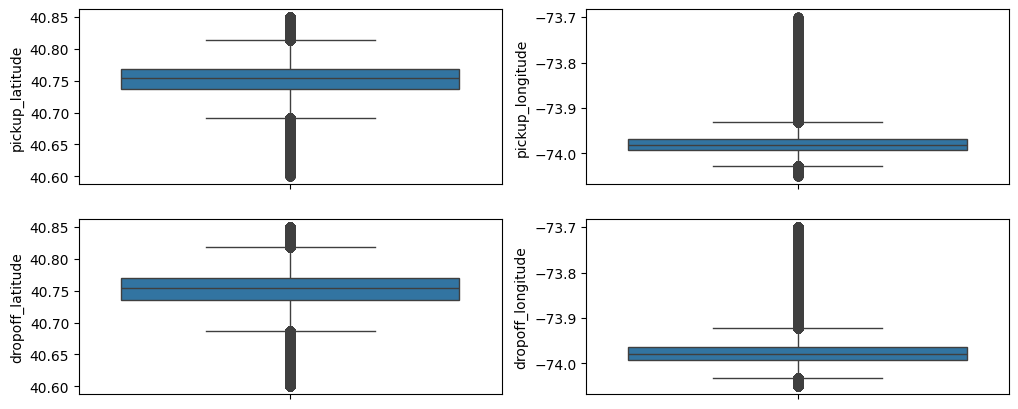

In [47]:
# box plot of locations columns

fig,(ax1,ax2) = plt.subplots(nrows=2,ncols=2,figsize=(12,5))

for i in range(0,4,1):

    if i<=1:
        sns.boxplot(data = df_location,y=cols[i],ax=ax1[i])

    else:
        sns.boxplot(data=df_location,y=cols[i],ax=ax2[i-2])

plt.show()

In [ ]:
# filtering the columns

pickup_coord_dataset = df[['pickup_latitude','pickup_longitude']]

pickup_coord_dataset

,pickup_latitude,pickup_longitude
npartitions=82,,
,float64,float64
,...,...
...,...,...
,...,...
,...,...


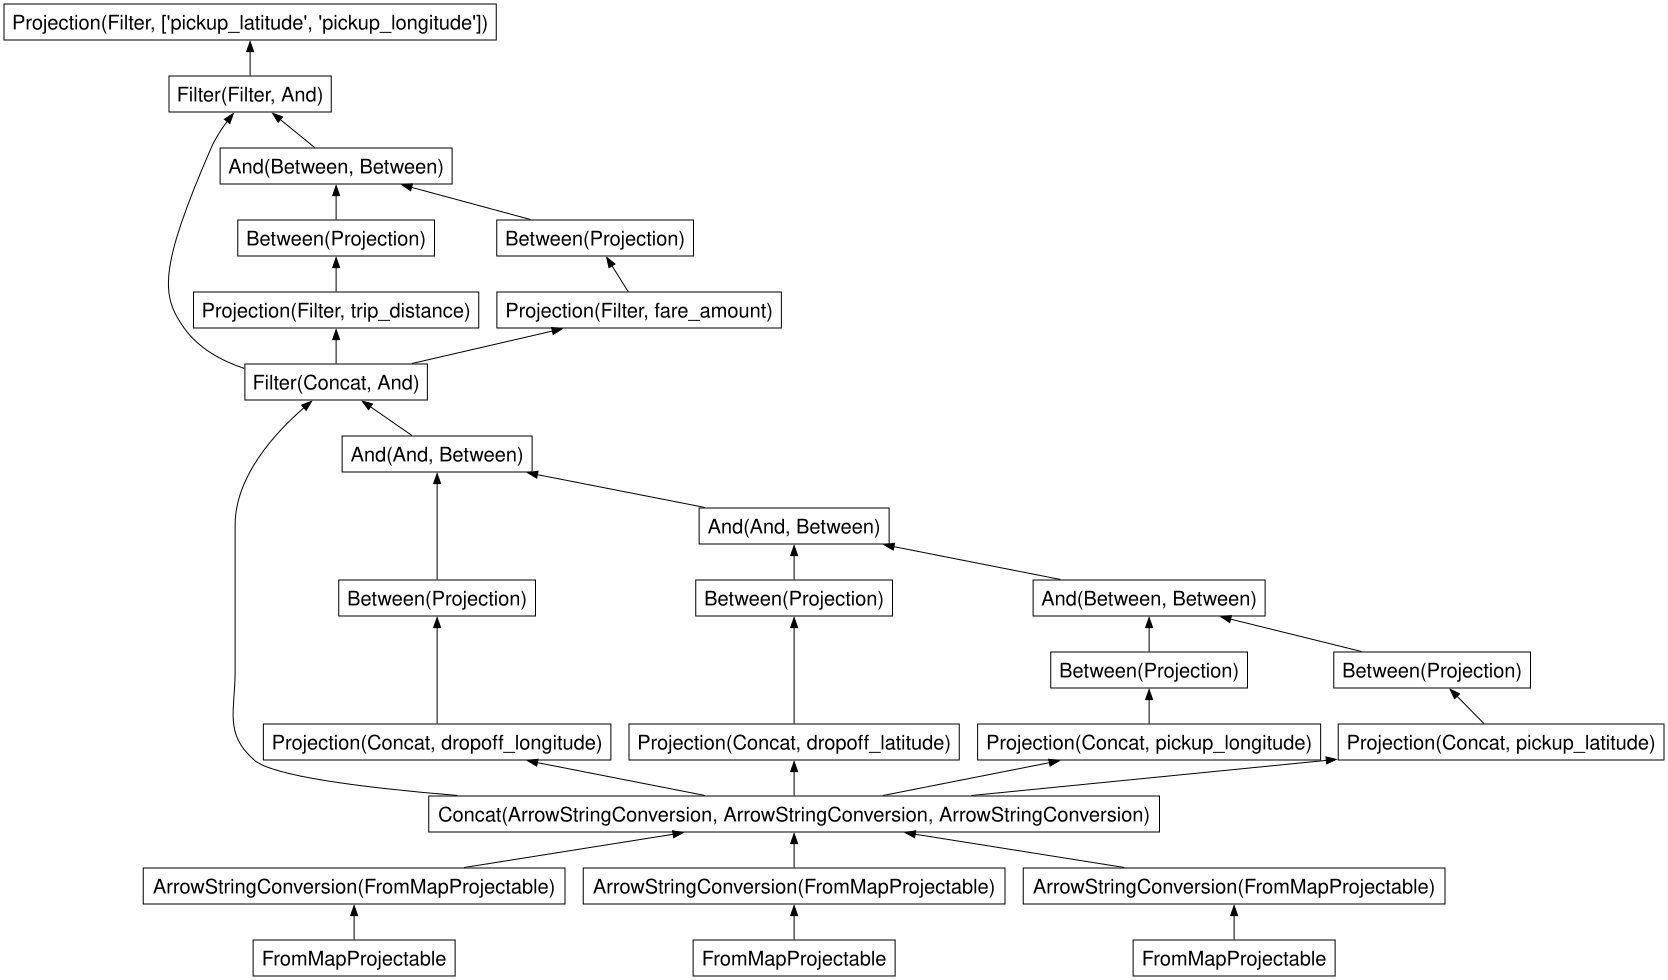

In [49]:
pickup_coord_dataset.visualize()

In [50]:
pickup_coord_dataset = pickup_coord_dataset.compute()

pickup_coord_dataset.shape

(33234199, 2)

In [51]:
pickup_coord_dataset

,pickup_latitude,pickup_longitude
0,40.734695,-73.990372
1,40.729912,-73.980782
2,40.679565,-73.984550
3,40.718990,-73.993469
4,40.781330,-73.960625
...,...,...
420269,40.644451,-73.790565
420270,40.641483,-73.788055
420271,40.646736,-73.789154
420273,40.774471,-73.977356


In [53]:
# saving pickup coordinate data

save_path = r"..\data\interim\location_data.csv"

df_location.to_csv(save_path,index=False)